# Notebook for setting up and prcoessing the RHINO calibration Gibbs Sampler

In [426]:
import numpy as np
import matplotlib.pyplot as plt
from sampler.reader import ObservationReader, ReflectionReader

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams.update({
    "font.family": "serif"
})

## Set up observation and reflections

In [427]:
observation = ObservationReader('simulated_data/sim_data.hdf5')
print(np.unique(observation.states_array))

reflection_dict = {'antenna':'simulated_data/antenna_gamma_src.s2p',
                   'heated_load':"simulated_data/heated_load_gamma_src.s2p",
                   'internal_load':'simulated_data/internal_load_gamma_src.s2p',
                   'long_open':'simulated_data/long_open_gamma_src.s2p',
                   'long_short':'simulated_data/long_short_gamma_src.s2p',
                   'open':'simulated_data/open_gamma_src.s2p',
                   'short':'simulated_data/short_gamma_src.s2p',
                   'receiver':'simulated_data/gamma_rec.s2p',
                   'noise_diode':'simulated_data/noise_diode_gamma_src.s2p'}

reflections = ReflectionReader(component_dict=reflection_dict,
                               output_frequencies=observation.freqs,
                               polynomial_interp=True,
                               polynomial_fitting_order=10)

['antenna' 'heated_load' 'internal_load' 'long_open' 'long_short' 'open'
 'short']


/Users/user/Desktop/RHINO/rhino-cal/sampler/reader.py:143: RankWarning: Polyfit may be poorly conditioned
  polyfit = np.polyfit(x=freq,
/Users/user/Desktop/RHINO/rhino-cal/sampler/reader.py:143: RankWarning: Polyfit may be poorly conditioned
  polyfit = np.polyfit(x=freq,
/Users/user/Desktop/RHINO/rhino-cal/sampler/reader.py:143: RankWarning: Polyfit may be poorly conditioned
  polyfit = np.polyfit(x=freq,
/Users/user/Desktop/RHINO/rhino-cal/sampler/reader.py:143: RankWarning: Polyfit may be poorly conditioned
  polyfit = np.polyfit(x=freq,
/Users/user/Desktop/RHINO/rhino-cal/sampler/reader.py:143: RankWarning: Polyfit may be poorly conditioned
  polyfit = np.polyfit(x=freq,
/Users/user/Desktop/RHINO/rhino-cal/sampler/reader.py:143: RankWarning: Polyfit may be poorly conditioned
  polyfit = np.polyfit(x=freq,
/Users/user/Desktop/RHINO/rhino-cal/sampler/reader.py:143: RankWarning: Polyfit may be poorly conditioned
  polyfit = np.polyfit(x=freq,
/Users/user/Desktop/RHINO/rhino-cal/sampl

# RFI Flag

In [428]:
from MomentRFI.MomentRFI import IterativeSurfaceFitter
from rfi_flagging.rfi_flagging import mask_by_state


## Set up basis functions

In [429]:
from sampler.linear_basis import BasisConstructor

In [430]:
gains_basis = BasisConstructor(observation.times,
                               observation.freqs,
                               n_time_modes=5,
                               n_freq_modes=5,
                               basis_function='polynomial',
                               time_norm=1*(observation.times[-1] - observation.times[0]),
                               frequency_norm=np.median(observation.freqs),
                               zero_time=True)

gains_basis = BasisConstructor(observation.times,
                               observation.freqs,
                               n_time_modes=5,
                               n_freq_modes=5,
                               basis_function='fourier',
                               time_norm=4*(observation.times[-1] - observation.times[0]),
                               frequency_norm=4*(observation.freqs[-1] - observation.freqs[0]),
                               zero_time=True)

unc_basis = BasisConstructor(observation.times,
                               observation.freqs,
                               n_time_modes=3,
                               n_freq_modes=3,
                               basis_function='polynomial',
                               time_norm=1*(observation.times[-1] - observation.times[0]),
                               frequency_norm=np.median(observation.freqs),
                               zero_time=True)

cos_basis = BasisConstructor(observation.times,
                               observation.freqs,
                               n_time_modes=3,
                               n_freq_modes=3,
                               basis_function='polynomial',
                               time_norm=1*(observation.times[-1] - observation.times[0]),
                               frequency_norm=np.median(observation.freqs),
                               zero_time=True)

sin_basis = BasisConstructor(observation.times,
                               observation.freqs,
                               n_time_modes=3,
                               n_freq_modes=3,
                               basis_function='polynomial',
                               time_norm=1*(observation.times[-1] - observation.times[0]),
                               frequency_norm=np.median(observation.freqs),
                               zero_time=True)

rx_basis = BasisConstructor(observation.times,
                               observation.freqs,
                               n_time_modes=3,
                               n_freq_modes=1,
                               basis_function='polynomial',
                               time_norm=1*(observation.times[-1] - observation.times[0]),
                               frequency_norm=np.median(observation.freqs),
                               zero_time=True)


noise_diode_basis = BasisConstructor(observation.times,
                               observation.freqs,
                               n_time_modes=1,
                               n_freq_modes=1,
                               basis_function='polynomial',
                               time_norm=1*(observation.times[-1] - observation.times[0]),
                               frequency_norm=np.median(observation.freqs),
                               zero_time=True)

# cal temperature set up: give the same time orders
cal_n_time_modes = 1


ambient_basis = BasisConstructor(observation.times,
                               observation.freqs,
                               n_time_modes=cal_n_time_modes,
                               n_freq_modes=1,
                               basis_function='polynomial',
                               time_norm=1*(observation.times[-1] - observation.times[0]),
                               frequency_norm=np.median(observation.freqs),
                               zero_time=True)

ambient_basis_y = BasisConstructor(observation.times,
                               0,
                               n_time_modes=cal_n_time_modes,
                               n_freq_modes=1,
                               basis_function='polynomial',
                               time_norm=1*(observation.times[-1] - observation.times[0]),
                               frequency_norm=np.median(observation.freqs),
                               zero_time=True)

heated_basis = BasisConstructor(observation.times,
                               observation.freqs,
                               n_time_modes=cal_n_time_modes,
                               n_freq_modes=1,
                               basis_function='polynomial',
                               time_norm=1*(observation.times[-1] - observation.times[0]),
                               frequency_norm=np.median(observation.freqs),
                               zero_time=True)

heated_basis_y = BasisConstructor(observation.times,
                               0,
                               n_time_modes=cal_n_time_modes,
                               n_freq_modes=1,
                               basis_function='polynomial',
                               time_norm=1*(observation.times[-1] - observation.times[0]),
                               frequency_norm=np.median(observation.freqs),
                               zero_time=True)
####

antenna_basis = BasisConstructor(observation.times,
                               observation.freqs,
                               n_time_modes=1,
                               n_freq_modes=1,
                               basis_function='polynomial',
                               time_norm=1*(observation.times[-1] - observation.times[0]),
                               frequency_norm=np.median(observation.freqs),
                               zero_time=True)

## Construct Operators

In [431]:
from sampler.operator_setup import generate_noise_wave_transfer_matrix
from sampler.operator_setup import generate_non_smooth_source_matrix, generate_smooth_source_matrix, generate_noise_wave_transfer_matrix
# Noise Wave Operator
X_noise_wave, nw_slice_dict = generate_noise_wave_transfer_matrix(observation,
                                                               reflections,
                                                               unc_basis,
                                                               cos_basis,
                                                               sin_basis,
                                                               rx_basis)
print(nw_slice_dict)
print(X_noise_wave.shape)


{'unc': slice(0, 9, None), 'cos': slice(9, 18, None), 'sin': slice(18, 27, None), 'rx': slice(27, 30, None)}
(368640, 30)


## Construct Antenna Operator

In [432]:
X_antenna = generate_smooth_source_matrix(observation,
                                          reflections,
                                          source_basis=antenna_basis,
                                          source_label='antenna')

# X_noise_diode = generate_smooth_source_matrix(observation,
#                                           reflections,
#                                           source_basis=noise_diode_basis,
#                                           source_label='noise_diode')

print(X_antenna.shape)

(368640, 1)


### Combine Noisewave and Antenna Operators

In [433]:
from sampler.operator_setup import concat_and_index_operators

X_ant_noisewave = np.concatenate((X_antenna, X_noise_wave), axis=1)

X_ant_noisewave, ant_noise_wave_slice_dict = concat_and_index_operators([X_antenna,
                                                                         #X_noise_diode,
                                                                         X_noise_wave],
                                                                         label_list=['antenna',
                                                                                     #'noise_diode',
                                                                                     'noise_wave'])

print(ant_noise_wave_slice_dict)

{'antenna': slice(0, 1, None), 'noise_wave': slice(1, 31, None)}


## Construct Calibration Source Operator

In [434]:
print(np.unique(observation.switch_states))

['antenna' 'heated_load' 'internal_load' 'long_open' 'long_short' 'open'
 'short']


In [435]:
X_ambient = generate_smooth_source_matrix(observation, reflections,
                                          source_basis=ambient_basis,
                                          source_label=['internal_load', 'long_open',
                                                        'long_short', 'open', 'short'])
X_heated = generate_smooth_source_matrix(observation, reflections,
                                         source_basis=heated_basis,
                                         source_label='heated_load')

X_calibrator, calibrator_slice_dict = concat_and_index_operators([X_ambient,
                                                                  X_heated],
                                                                  ['ambient',
                                                                   'heated'])


from sampler.priors import generate_smooth_thermistor_operator_matrix

Y_ambient = generate_smooth_thermistor_operator_matrix(observation,
                                          source_basis=ambient_basis_y,
                                          source_label=['internal_load', 'long_open',
                                                        'long_short', 'open', 'short'])


Y_heated = generate_smooth_thermistor_operator_matrix(observation,
                                         source_basis=heated_basis_y,
                                         source_label='heated_load')

Y_calibrator, calibrator_slice_dict_y = concat_and_index_operators([Y_ambient,
                                                                  Y_heated],
                                                                  ['ambient',
                                                                   'heated'])

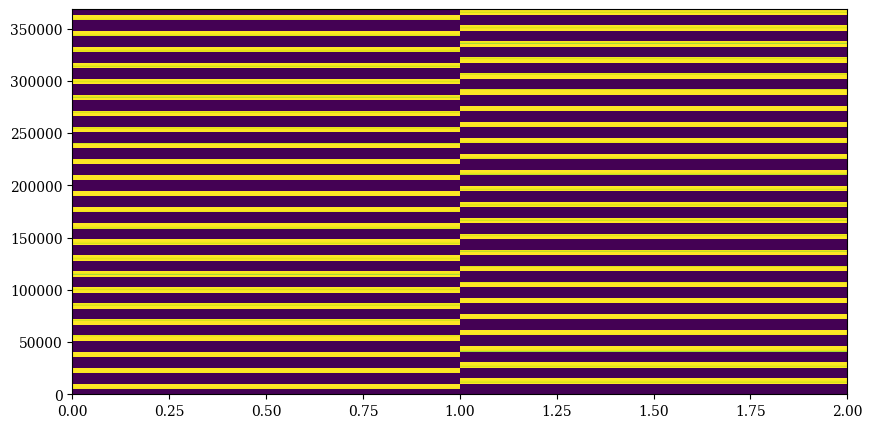

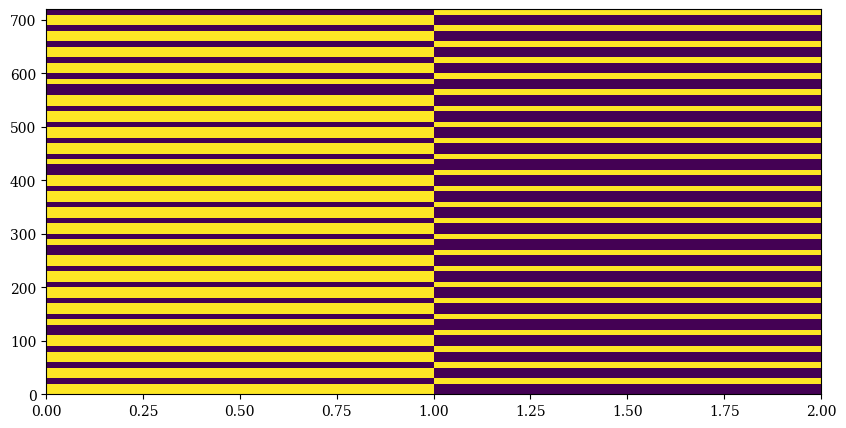

{'ambient': slice(0, 1, None), 'heated': slice(1, 2, None)}


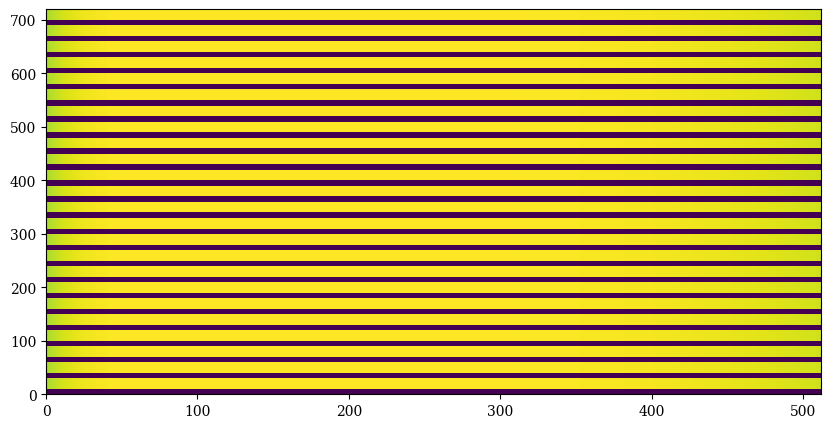

In [436]:

plt.pcolormesh(X_calibrator)
plt.show()

plt.pcolormesh(Y_calibrator)
plt.show()

print(calibrator_slice_dict)

cont = X_calibrator @ np.ones_like(X_calibrator[0])
cont = np.reshape(cont, shape=observation.data_waterfall.shape)
plt.pcolormesh(cont)
plt.show()

In [437]:
print(np.unique(observation.switch_states))

['antenna' 'heated_load' 'internal_load' 'long_open' 'long_short' 'open'
 'short']


### Construct Cal Source Priors

In [438]:
from sampler.priors import setup_probe_cal_priors
cal_source_priors, cal_source_prior_inv_cov = setup_probe_cal_priors(observation,
                                           source_temp_dict={'heated':'heated_load',
                                                             'ambient':['internal_load',
                                                                        'open',
                                                                        'short',
                                                                        'long_open',
                                                                        'long_short']},
                                                                        temp_std=1)


In [439]:
### Attempt a Weiner solution fit

from sampler.gibbs_sample import construct_gcr_lhs, construct_gcr_rhs, solve_gcr



cal_source_lhs = construct_gcr_lhs(linear_operator=Y_calibrator,
                                   inv_data_cov=cal_source_prior_inv_cov,
                                   inv_prior_cov=None,)
cal_source_rhs = construct_gcr_rhs(linear_operator=Y_calibrator,
                                   data=cal_source_priors,
                                   inv_data_cov=cal_source_prior_inv_cov,
                                   omega_data=np.zeros_like(cal_source_priors),
                                   priors=None,
                                   inv_prior_cov=None,
                                   weiner_solution=True,)

init_calibrator_solution = solve_gcr(cal_source_lhs, cal_source_rhs,linalg_init=False,
                                     atol=1e-10, rtol=1e-12, maxiter=int(1e6))


print(init_calibrator_solution)


# ambient_amps, heated_amps = init_calibrator_solution[:4], init_calibrator_solution[4:]
# print(ambient_amps)
# print(heated_amps)

# reconstructed_ambient = ambient_basis.basis_matrix @ ambient_amps
# reconstructed_heated = ambient_basis.basis_matrix @ heated_amps

# plt.pcolormesh(np.reshape(reconstructed_ambient, shape=observation.data_waterfall.shape))
# plt.colorbar()
# plt.show()

# plt.pcolormesh(np.reshape(reconstructed_heated, shape=observation.data_waterfall.shape))
# plt.colorbar()
# plt.show()

[292.99950478 443.00006558]


In [440]:
# cal_source_priors = np.array([np.mean(observation.temperatures['ambient']),
#                                      np.mean(observation.temperatures['heated'])])
# cal_source_prior_inv_cov = np.ones_like(cal_source_priors) * (1 / 0.0005)

print(cal_source_prior_inv_cov)

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.

In [441]:
## Construct cal source priors from raw temperatures

## Gain Operator

In [442]:
U_gain = gains_basis.basis_matrix
print(U_gain.shape)
# plt.pcolormesh(U_gain)
# plt.show()

(368640, 50)


In [443]:
print(observation.temperatures)

{'heated': array([443.00727958, 442.98869553, 443.00971527, 442.98512644,
       442.9880819 , 443.00253002, 442.99037857, 443.00653636,
       442.99701945, 443.0050158 , 443.00151629, 443.00721142,
       442.99884182, 442.99512832, 443.01396716, 442.97517723,
       443.00243222, 443.0002369 , 443.01650307, 442.99335364,
       443.01075665, 442.99799184, 443.00591027, 442.99857276,
       443.0068866 , 443.00107695, 442.99788436, 442.98864759,
       442.99886019, 443.00498741, 442.98646438, 442.99118713,
       442.98920779, 442.98462683, 443.01117304, 442.98976268,
       442.99132884, 443.00158571, 442.99258815, 442.97791833,
       443.00360952, 443.00438604, 443.00640053, 442.98893531,
       442.99932498, 442.99705767, 443.01108488, 442.99674553,
       442.97519364, 443.01493043, 442.98035468, 442.98969956,
       443.00091326, 442.99465264, 442.99525441, 442.98591156,
       443.00639207, 442.99994229, 442.99672674, 443.00408609,
       442.98898097, 443.00396861, 442.99157

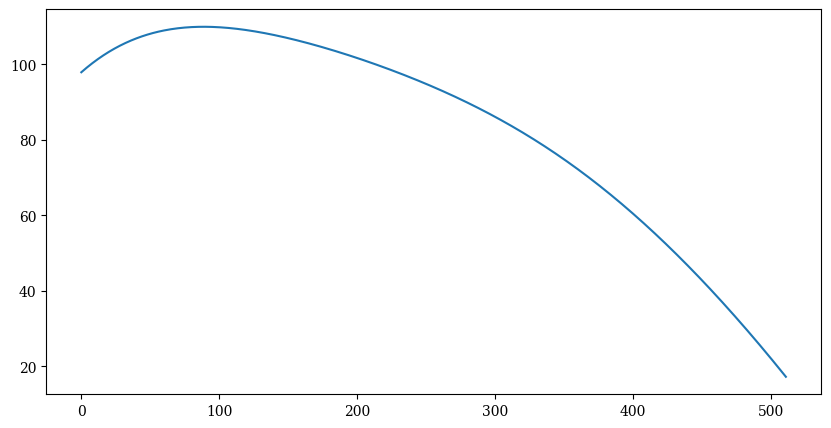

In [444]:
# get an initial guess of the gains params

def init_gain_guess(observation_obj: ObservationReader,
                    reflections_obj: ReflectionReader,
                    gains_basis: BasisConstructor,
                    noise_source_label: str = "heated_load",
                    load_label: str = 'internal_load',
                    noise_source_temp: int | None = None):

    noise_source_mask = (observation_obj.states_array == noise_source_label)
    load_mask = (observation_obj.states_array == load_label)
    p_ns = observation_obj.data_waterfall[noise_source_mask].mean(axis=0)
    p_l = observation_obj.data_waterfall[load_mask].mean(axis=0)

    if noise_source_temp is not None: t_ns = noise_source_temp
    else:
        t_ns = np.mean(observation_obj.temperatures['heated'])
    t_l = np.mean(observation_obj.temperatures['ambient'])

    gamma_rec = reflections_obj.s11_dict['receiver']

    mean_gain = (p_ns - p_l) / ((t_ns - t_l) * (1 - np.power(np.abs(gamma_rec), 2)))

    fitting_gain = np.zeros_like(observation.data_waterfall)
    fitting_gain[:,:] = mean_gain
    fitting_gain = fitting_gain.flatten()
    init_amp_guess = np.linalg.lstsq(gains_basis.basis_matrix, fitting_gain)[0]

    return init_amp_guess


# def gain_correction(observation_obj: ObservationReader,
#                     reflections_obj: ReflectionReader,
#                     noise_source_label: str = "heated_load",
#                     load_label: str = 'internal_load',
#                     polynomial_order: int,
#                     noise_source_temp: int | None = None,):
    
#     noise_source_mask = (observation_obj.states_array == noise_source_label)
#     load_mask = (observation_obj.states_array == load_label)
#     p_ns = observation_obj.data_waterfall[noise_source_mask].mean(axis=0)
#     p_l = observation_obj.data_waterfall[load_mask].mean(axis=0)
    


init_gain_amps = init_gain_guess(observation, reflections, gains_basis)

recov_init_gains = gains_basis.basis_matrix @ init_gain_amps
recov_init_gains = np.reshape(recov_init_gains,
                              shape=observation.data_waterfall.shape)

plt.plot(np.mean(recov_init_gains, axis=0))

# Set up Gibbs Sampler

In [445]:
from sampler.gibbs_sample import sample_loop

In [446]:
print(init_calibrator_solution)

[292.99950478 443.00006558]


In [447]:
param_dict = sample_loop(data=observation.data_waterfall.flatten(),
                         N=observation.Nw.flatten(),
                         U_gain=U_gain,
                         X_ant_nw=X_ant_noisewave,
                         X_cal_src=X_calibrator,
                         init_gain_amps=init_gain_amps,
                         init_cal_src_amps=init_calibrator_solution,
                         init_ant_nw_amps=np.ones_like(X_ant_noisewave[0]),
                         cal_src_priors=cal_source_priors,
                         inv_cal_src_prior_cov=cal_source_prior_inv_cov, n_iter=500,
                         fix_cal_source=False,
                         Y_cal_src=Y_calibrator,
                         verbose=True,
                         chi_square_stats=True)

d_cont  [527.73787594 534.64375618 537.97006508 ... 506.76779062 509.25582776
 507.38979763]
inv_cont_cov  [0.00321147 0.00298224 0.00277602 ... 0.0012015  0.00120375 0.00120611]
p_ant_nw - 0
[ 2528.14520162    70.44105016  -178.61249074    96.20264758
  -253.42097305   519.84167966  -268.25289923   197.96520389
  -376.90865768   484.02867272   213.95752019  -418.431233
   206.35690191  -692.96483287  1380.95911435  -668.91439475
   368.6222953   -724.59436476   393.28751873  1299.47604544
 -2670.7498165   1364.92747513 -1100.44541931  2492.77804603
 -1348.69572297   183.77173442  -525.35868442   379.05282818
    11.85526943   213.63891796   274.82460795]
d_gain  [101.67365614 102.10639737 101.8552934  ...  18.24071627  17.83395571
  17.34124086]
d_gain_inv_cov  [0.03815753 0.0380042  0.0378529  ... 1.16549842 1.22923192 1.29863753]
p_gain - 0
[ 3.41726274e+01 -9.75971098e+01 -4.09861684e+01  3.87499895e+01
 -8.49975293e+00 -2.26415581e+02  8.23729981e+00  4.20907274e+01
  4.94934927e+

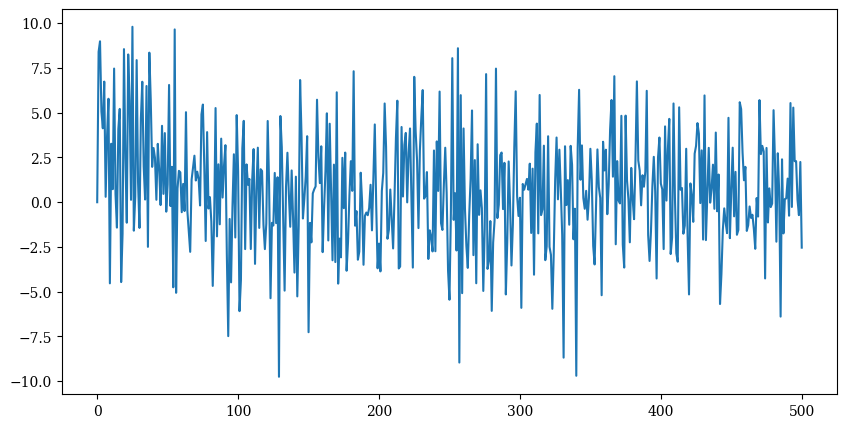

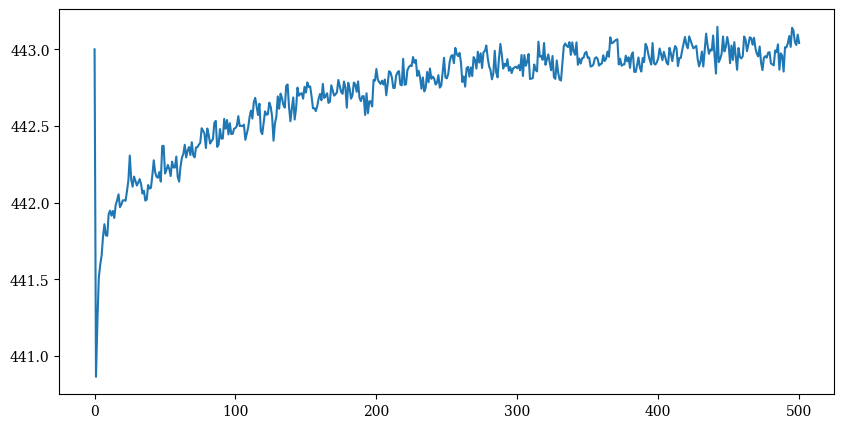

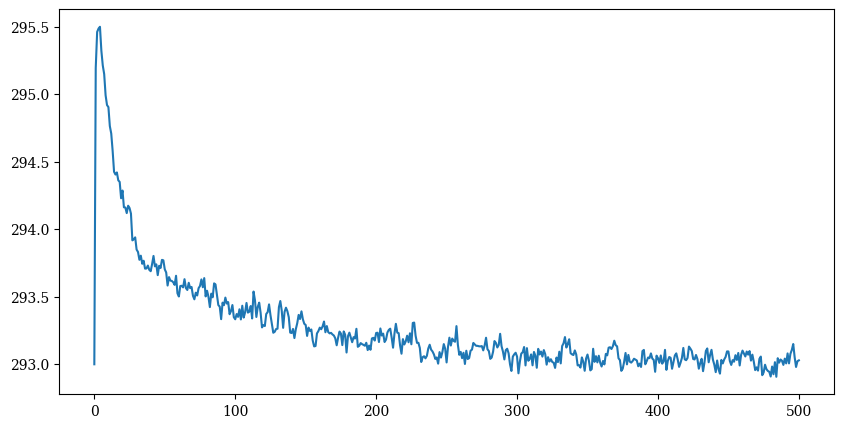

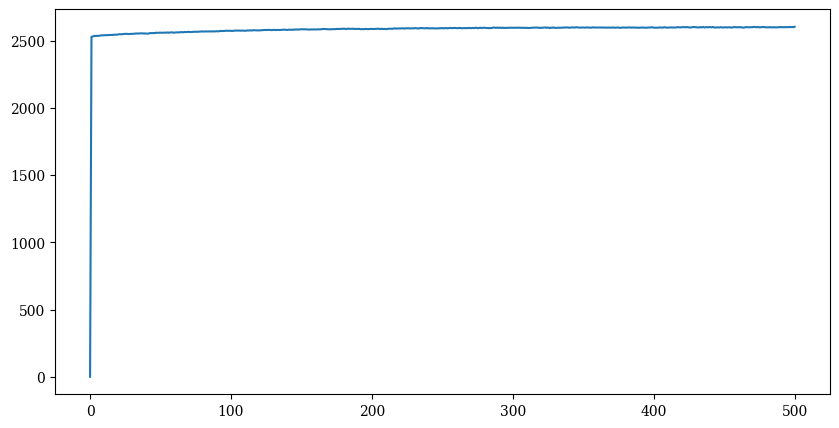

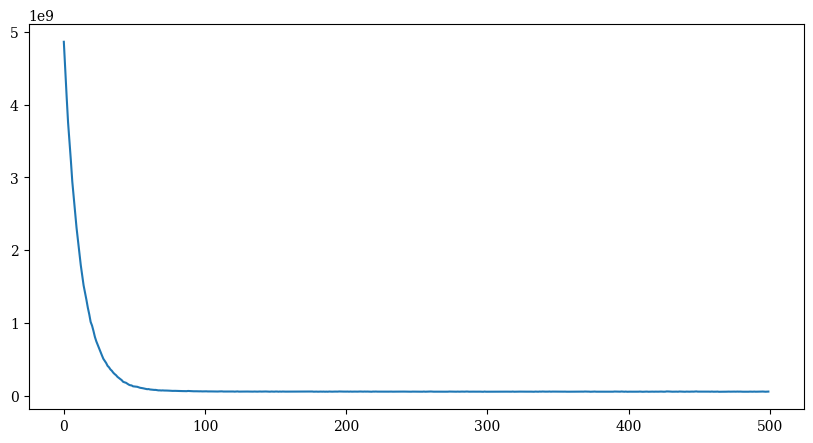

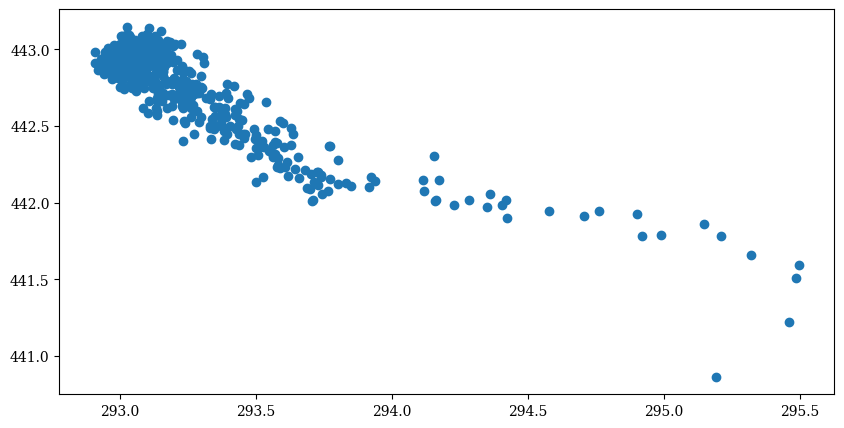

In [448]:
plt.plot(param_dict['all_p_gain'][:,-1])
plt.show()
plt.plot(param_dict['all_p_cal_src'][:, -1])
plt.show()
plt.plot(param_dict['all_p_cal_src'][:, 0])
plt.show()
plt.plot(param_dict['all_p_ant_nw'][:, 0])
plt.show()

plt.plot(param_dict['all_chi_squared_stats'])
plt.show()

plt.scatter(param_dict['all_p_cal_src'][:, 0], param_dict['all_p_cal_src'][:, 1])
plt.show()

In [449]:
param_dict = sample_loop(data=observation.data_waterfall.flatten(),
                         N=observation.Nw.flatten(),
                         U_gain=U_gain,
                         X_ant_nw=X_ant_noisewave,
                         X_cal_src=X_calibrator,
                         init_gain_amps=param_dict['all_p_gain'][-1],
                         init_cal_src_amps=param_dict['all_p_cal_src'][-1],
                         init_ant_nw_amps=param_dict['all_p_ant_nw'][-1],
                         cal_src_priors=cal_source_priors,
                         inv_cal_src_prior_cov=cal_source_prior_inv_cov,
                         n_iter=2000,
                         fix_cal_source=False,
                         Y_cal_src=Y_calibrator,
                         verbose=False,
                         chi_square_stats=True)

chi_sq:  55380606.706250265
Gibbs Sample - 0 / 2000
chi_sq:  55270602.92165595
Gibbs Sample - 50 / 2000
chi_sq:  55563096.07945942
Gibbs Sample - 100 / 2000
chi_sq:  55738451.922105014
Gibbs Sample - 150 / 2000
chi_sq:  55209085.15678646
Gibbs Sample - 200 / 2000
chi_sq:  55177000.39960922
Gibbs Sample - 250 / 2000
chi_sq:  54336757.88409292
Gibbs Sample - 300 / 2000
chi_sq:  54417769.44113909
Gibbs Sample - 350 / 2000
chi_sq:  54964720.56228642
Gibbs Sample - 400 / 2000
chi_sq:  55780072.574523255
Gibbs Sample - 450 / 2000
chi_sq:  54655753.893844336
Gibbs Sample - 500 / 2000
chi_sq:  55951694.39078962
Gibbs Sample - 550 / 2000
chi_sq:  55246792.15329801
Gibbs Sample - 600 / 2000
chi_sq:  55672740.19709038
Gibbs Sample - 650 / 2000
chi_sq:  57173842.14207202
Gibbs Sample - 700 / 2000
chi_sq:  56858857.06291212
Gibbs Sample - 750 / 2000
chi_sq:  56435965.93784182
Gibbs Sample - 800 / 2000
chi_sq:  55794123.16409083
Gibbs Sample - 850 / 2000
chi_sq:  54570192.391825676
Gibbs Sample - 90

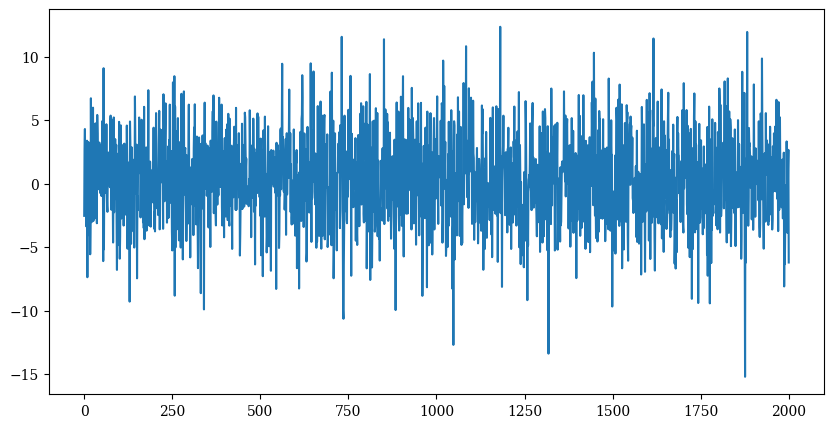

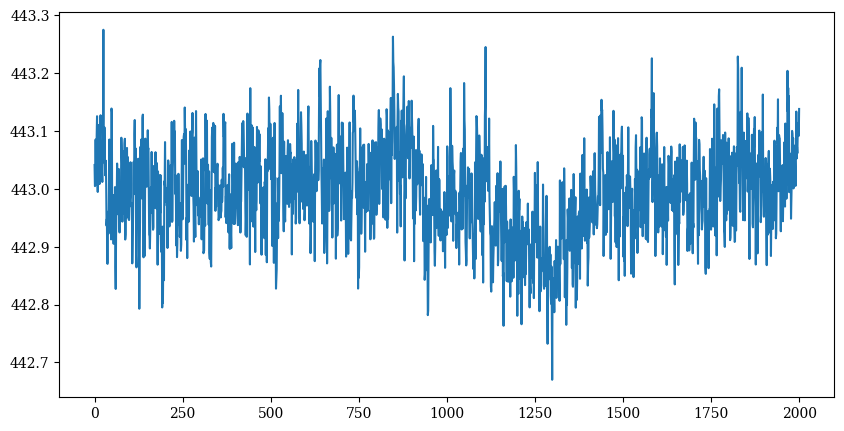

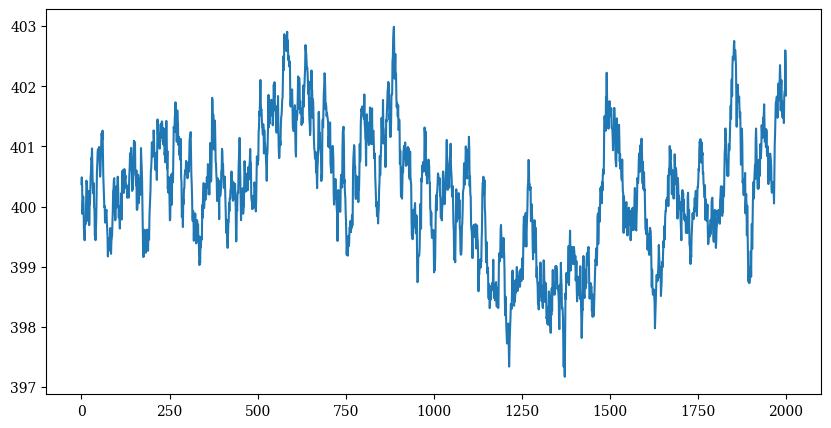

442.99303774051856


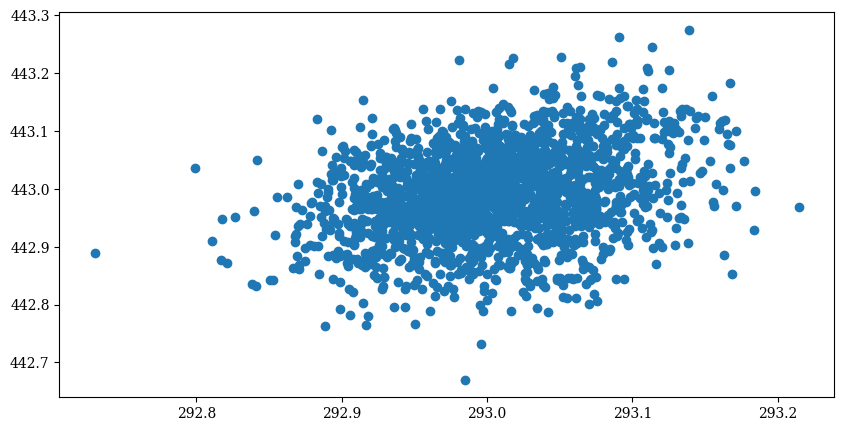

In [450]:
plt.plot(param_dict['all_p_gain'][:,-1])
plt.show()
plt.plot(param_dict['all_p_cal_src'][:, -1])
plt.show()
plt.plot(param_dict['all_p_ant_nw'][:, -1])
plt.show()

print(np.mean(param_dict['all_p_cal_src'][:, -1]))

plt.scatter(param_dict['all_p_cal_src'][:, 0], param_dict['all_p_cal_src'][:, 1])
plt.show()



[ -8.02899619  16.12072262  -8.07693308  10.28864504 -50.68663538
  34.47044448  -1.34072327  26.68179486 278.3029712  -30.22891714
  60.54396771 -30.07039754  25.57274622 -17.62117307  -8.97519986
  -3.50806083   2.53809441  50.9143421   -2.55819862   7.14103724
  -4.37549868  11.66310686 -15.45088509   8.037801    -6.00069966
 -10.3805576   74.15291459   1.23579124   3.68850662 400.25984169]


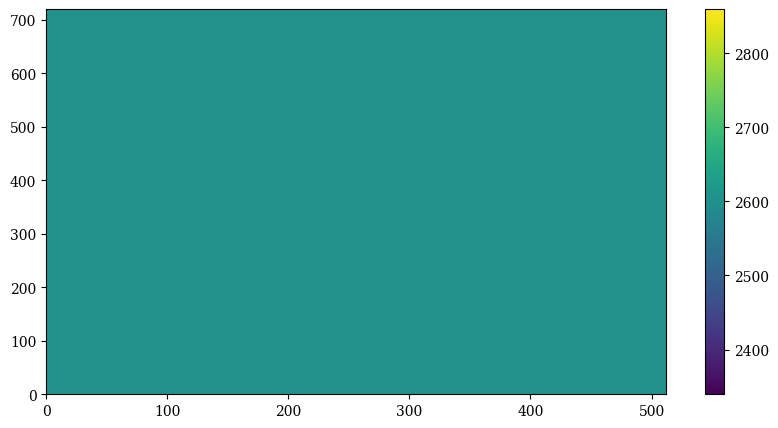

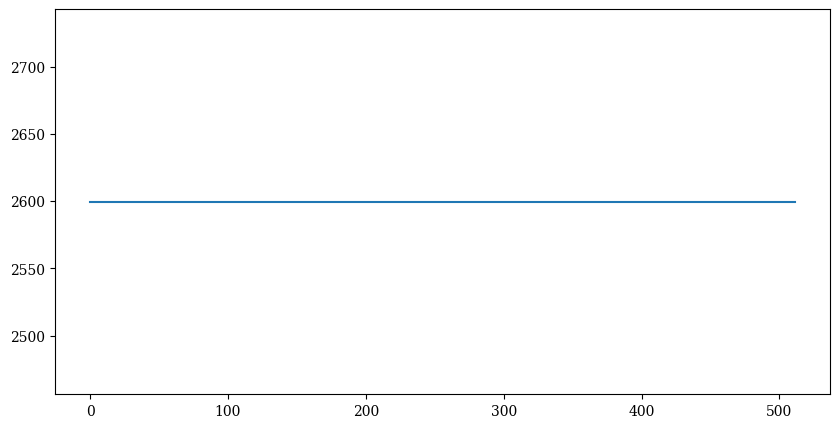

In [451]:
# Recovered Antenna

median_p_ant_nw = np.mean(param_dict['all_p_ant_nw'], axis=0)
median_p_ant = median_p_ant_nw[:len(X_antenna[0])]
median_p_nw = median_p_ant_nw[len(X_antenna[0]):]
print(median_p_nw)


reconstructed_antenna = antenna_basis.basis_matrix @ median_p_ant
reconstructed_antenna = np.reshape(reconstructed_antenna, shape=observation.data_waterfall.shape)

plt.pcolormesh(reconstructed_antenna)
plt.colorbar()
plt.show()

plt.plot(reconstructed_antenna.mean(axis=0))
plt.show()

[-9.50845333e+00  9.89899637e+01 -2.08556033e+02  1.08697471e+02
 -1.33083738e+01  3.31207662e+01 -7.88323687e+00  3.60887639e+01
 -1.59516593e+01  3.07063738e+00 -2.83296447e+01  2.08586993e+01
 -2.47359842e+00 -5.83278501e-02  8.29717328e-01  1.07719901e+01
 -1.34661096e+01 -1.30485365e+00 -2.85482406e-01 -4.36056946e-01
 -1.58533321e+00  2.93221281e+00 -7.78272340e-01  1.78682917e+00
 -7.09704838e-01  0.00000000e+00  3.08439946e+01 -9.16365482e+01
 -1.94190594e+01  1.12355594e+01 -3.36102816e+01  8.28570020e+01
 -1.18844402e+01  6.41265652e+00  3.34697745e-01  1.09436639e+01
 -4.37524962e+01 -3.43376126e+00  3.43718819e+00 -1.96670005e+00
 -8.38913910e-01  1.21989112e+01 -8.73930241e-01  1.59461562e+00
 -7.38177072e-01 -8.99345268e-01  5.11923879e-01 -1.38766494e+00
  3.02421938e-01  3.16510396e-01]


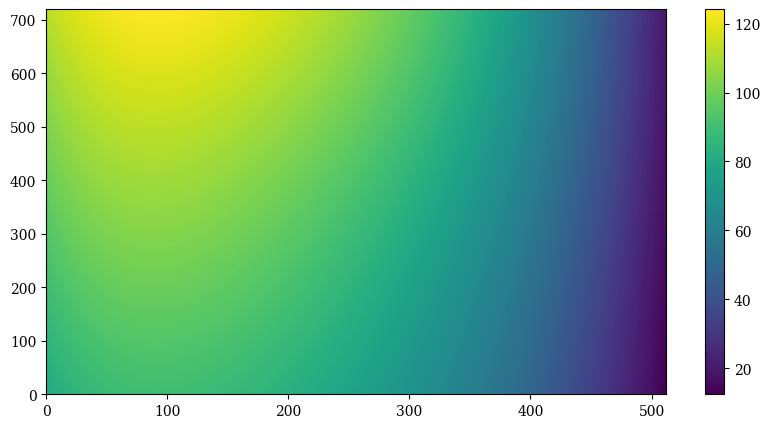

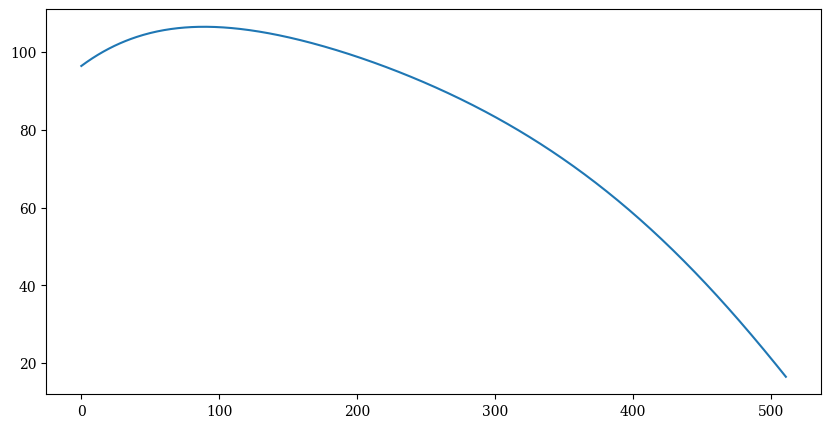

In [452]:
median_gains = np.median(param_dict['all_p_gain'], axis=0)

print(median_gains)

reconstructed_gains = gains_basis.basis_matrix @ median_gains

reconstructed_gains = np.reshape(reconstructed_gains, shape=observation.data_waterfall.shape)

plt.pcolormesh(reconstructed_gains)
plt.colorbar()
plt.show()

plt.plot(np.mean(reconstructed_gains, axis=0))
plt.show()

In [453]:
import h5py
sim_filepath = 'simulated_data/sim_data.hdf5_sim'
with h5py.File(sim_filepath) as f:
    t_unc_sim = f['t_unc'][()]
    t_sin_sim = f['t_sin'][()]
    t_cos_sim = f['t_cos'][()]
    t_rx_sim = f['t_0'][()]
    gain_sim = f['gains'][()]

## Gain Recovery

[-9.50845333e+00  9.89899637e+01 -2.08556033e+02  1.08697471e+02
 -1.33083738e+01  3.31207662e+01 -7.88323687e+00  3.60887639e+01
 -1.59516593e+01  3.07063738e+00 -2.83296447e+01  2.08586993e+01
 -2.47359842e+00 -5.83278501e-02  8.29717328e-01  1.07719901e+01
 -1.34661096e+01 -1.30485365e+00 -2.85482406e-01 -4.36056946e-01
 -1.58533321e+00  2.93221281e+00 -7.78272340e-01  1.78682917e+00
 -7.09704838e-01  0.00000000e+00  3.08439946e+01 -9.16365482e+01
 -1.94190594e+01  1.12355594e+01 -3.36102816e+01  8.28570020e+01
 -1.18844402e+01  6.41265652e+00  3.34697745e-01  1.09436639e+01
 -4.37524962e+01 -3.43376126e+00  3.43718819e+00 -1.96670005e+00
 -8.38913910e-01  1.21989112e+01 -8.73930241e-01  1.59461562e+00
 -7.38177072e-01 -8.99345268e-01  5.11923879e-01 -1.38766494e+00
  3.02421938e-01  3.16510396e-01]


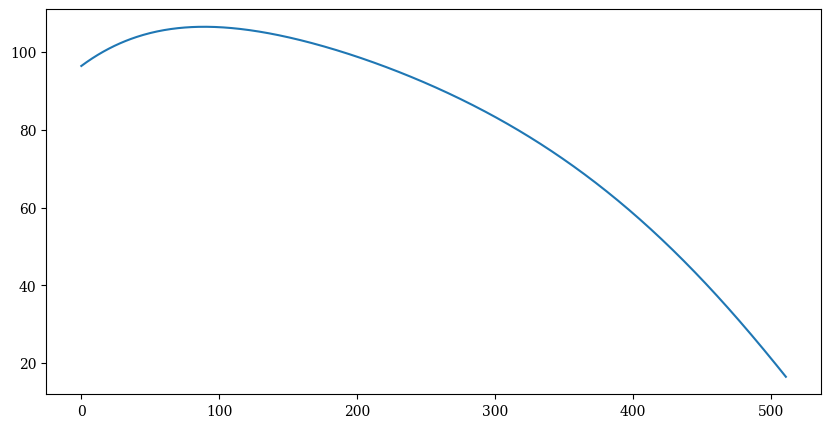

In [454]:
median_gains = np.median(param_dict['all_p_gain'], axis=0)
mean_gains = np.mean(param_dict['all_p_gain'], axis=0)
print(median_gains)

reconstructed_gains = gains_basis.basis_matrix @ median_gains

reconstructed_gains = np.reshape(reconstructed_gains, shape=observation.data_waterfall.shape)

plt.plot(np.mean(reconstructed_gains, axis=0))
plt.show()

In [455]:
def compare_sim_and_recontructed(simulated_surface,
                                 basis_obj:BasisConstructor,
                                 amplitudes,
                                 times,
                                 freqs,
                                 cmap_rec='viridis',
                                 cmap_res='RdBu',
                                 perc_diff=False,
                                 surface_label='',
                                 residvminvmax=None,
                                 figsize=(10,8)):
    fig, (ax1, ax2, ax3) = plt.subplots(nrows=3, sharex=True, layout='constrained',
                                        figsize=figsize)

    recovered_surface = basis_obj.basis_matrix @ amplitudes
    recovered_surface = np.reshape(recovered_surface, shape=simulated_surface.shape)

    vmin = np.min(np.array([simulated_surface, recovered_surface]))
    vmax = np.max(np.array([simulated_surface, recovered_surface]))
    
    im1 = ax1.pcolormesh(freqs, times, simulated_surface, cmap=cmap_rec, vmin=vmin, vmax=vmax)
    ax1.set_title('True Simulated')

    im2 = ax2.pcolormesh(freqs, times, recovered_surface, cmap=cmap_rec, vmin=vmin, vmax=vmax)
    ax2.set_title('Recovered')

    if perc_diff:
        res = 200 * (recovered_surface - simulated_surface) / (recovered_surface+simulated_surface)
    else:
        res = recovered_surface - simulated_surface
    

    if residvminvmax is not None:
        im3 = ax3.pcolormesh(freqs, times, res, cmap=cmap_res,
                                 vmin=-residvminvmax,
                                 vmax=residvminvmax)
    else:
        im3 = ax3.pcolormesh(freqs, times, res, cmap=cmap_res)

    fig.colorbar(im1, ax=[ax1, ax2], label=surface_label)

    if perc_diff:
        res_label='% Difference'
    else:
        res_label='Residual [K]'
    fig.colorbar(im3, ax=ax3, label=res_label)

    fig.supxlabel('Freqs [Hz]')
    fig.supylabel('Time [s]')
    plt.show()
    

## Noise Wave Param Recovery

In [456]:
param_dict['all_p_ant_nw'][ant_noise_wave_slice_dict['noise_wave']]

mean_ant_nw = param_dict['all_p_ant_nw'].mean(axis=0)

median_ant_nw = np.mean(param_dict['all_p_ant_nw'], axis=0)

# print(ant_noise_wave_slice_dict['noise_wave'])

mean_nw = median_ant_nw[ant_noise_wave_slice_dict['noise_wave']]
print(nw_slice_dict)

mean_unc = mean_nw[nw_slice_dict['unc']]
mean_cos = mean_nw[nw_slice_dict['cos']]
mean_sin = mean_nw[nw_slice_dict['sin']]
mean_rx = mean_nw[nw_slice_dict['rx']]

print(mean_unc, mean_cos, mean_sin, mean_rx)

{'unc': slice(0, 9, None), 'cos': slice(9, 18, None), 'sin': slice(18, 27, None), 'rx': slice(27, 30, None)}
[ -8.02899619  16.12072262  -8.07693308  10.28864504 -50.68663538
  34.47044448  -1.34072327  26.68179486 278.3029712 ] [-30.22891714  60.54396771 -30.07039754  25.57274622 -17.62117307
  -8.97519986  -3.50806083   2.53809441  50.9143421 ] [ -2.55819862   7.14103724  -4.37549868  11.66310686 -15.45088509
   8.037801    -6.00069966 -10.3805576   74.15291459] [  1.23579124   3.68850662 400.25984169]


In [457]:
figsize=(5,10)

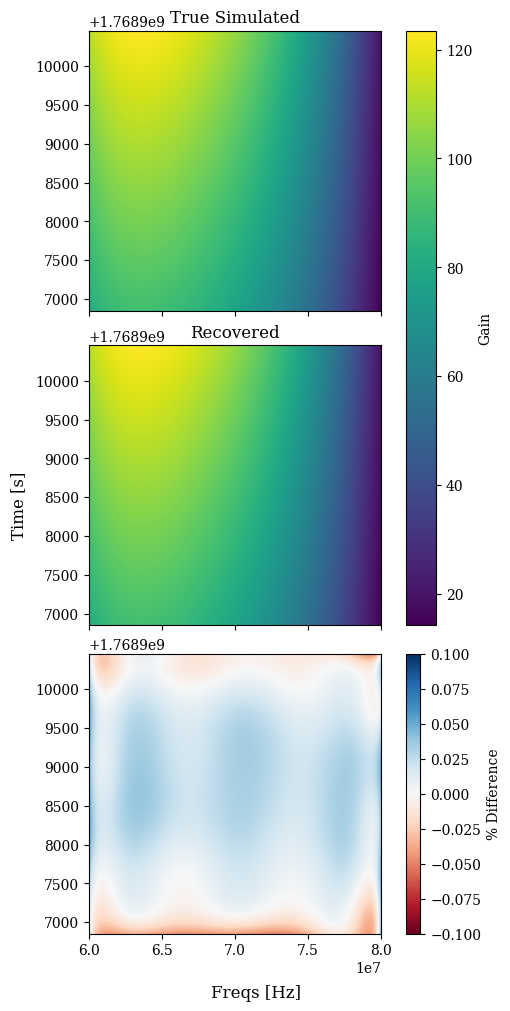

In [458]:
compare_sim_and_recontructed(gain_sim,
                             gains_basis,
                             mean_gains,
                             observation.times,
                             observation.freqs,
                             surface_label='Gain',
                             perc_diff=True,
                             residvminvmax=0.1,
                             figsize=figsize)

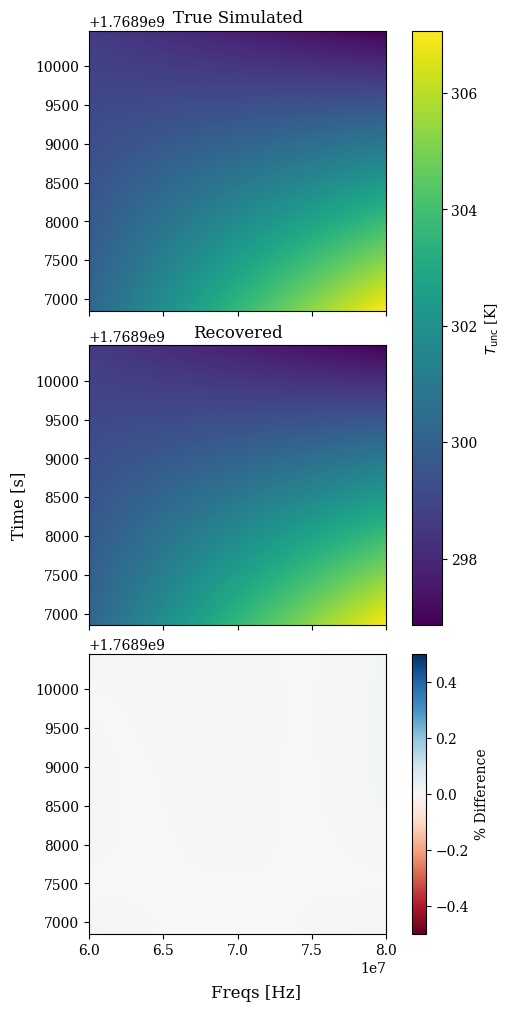

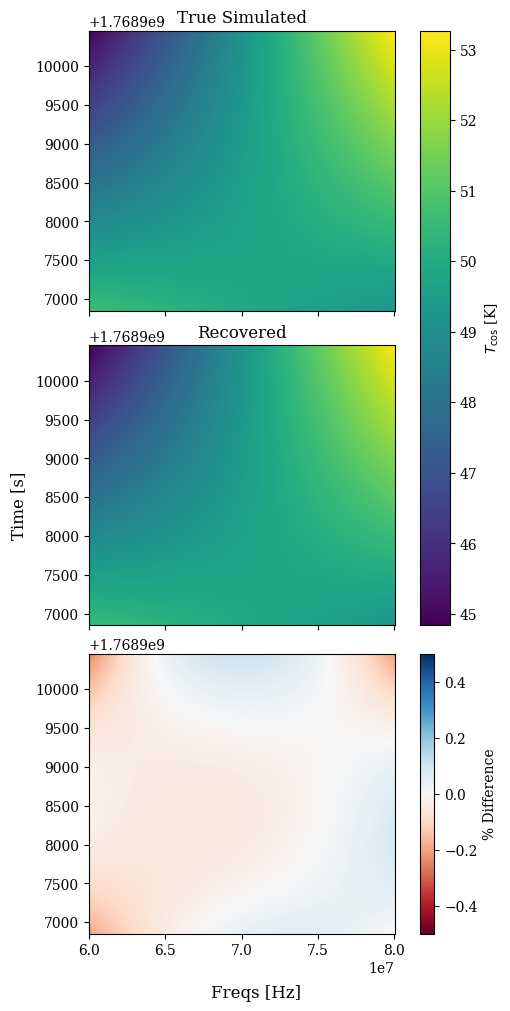

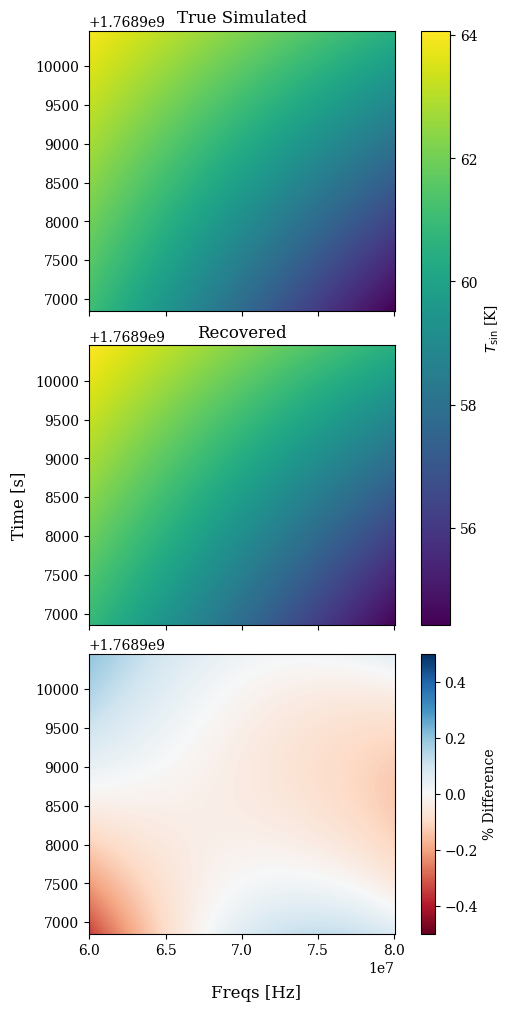

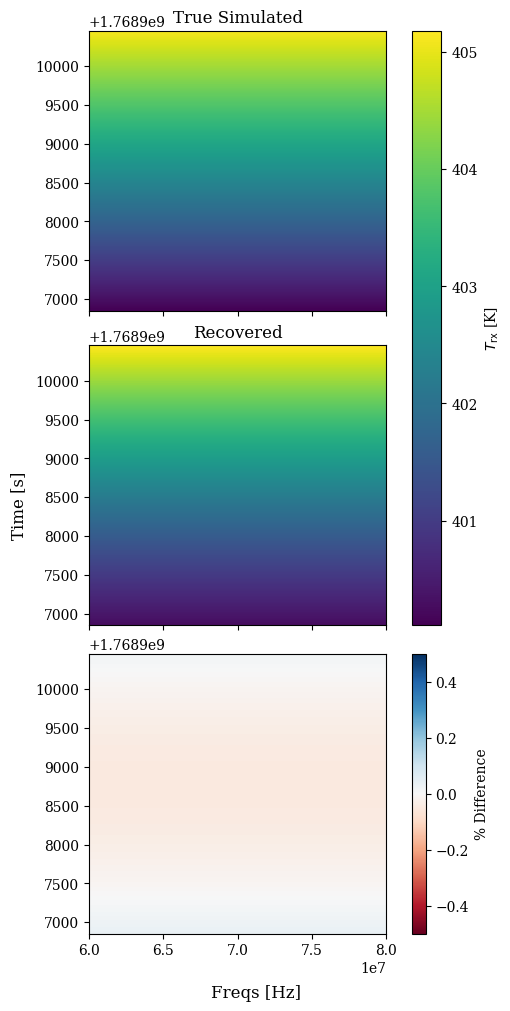

In [459]:
figsize=(5,10)

compare_sim_and_recontructed(t_unc_sim,
                             unc_basis,
                             mean_unc,
                             observation.times,
                             observation.freqs,
                             perc_diff=True,
                             residvminvmax=0.5,
                             surface_label=r'$T_{\rm unc}$ [K]',
                             figsize=figsize)
compare_sim_and_recontructed(t_cos_sim,
                             cos_basis,
                             mean_cos,
                             observation.times,
                             observation.freqs,
                             perc_diff=True,
                             residvminvmax=0.5,
                             surface_label=r'$T_{\rm cos}$ [K]',
                             figsize=figsize)
compare_sim_and_recontructed(t_sin_sim,
                             sin_basis,
                             mean_sin,
                             observation.times,
                             observation.freqs,
                             perc_diff=True,
                             residvminvmax=0.5,
                             surface_label=r'$T_{\rm sin}$ [K]',
                             figsize=figsize)
compare_sim_and_recontructed(t_rx_sim,
                             rx_basis,
                             mean_rx,
                             observation.times,
                             observation.freqs,
                             perc_diff=True,
                             residvminvmax=0.5,
                             surface_label=r'$T_{\rm rx}$ [K]',
                             figsize=figsize)

In [460]:
def plot_corner(
    chains: np.ndarray,
    labels: list[str] | None = None,
    truths: list[float] | None = None,
    title: str | None = None,
    **corner_kwargs,
):
    """
    Plot posterior densities and parameter correlations using corner.py.

    Parameters
    ----------
    chains : np.ndarray
        Array of parameter chains with shape:
        (n_samples, n_parameters)

    labels : list[str], optional
        Names of the parameters.

    truths : list[float], optional
        True/reference values for each parameter.

    title : str, optional
        Optional figure title.

    **corner_kwargs
        Additional keyword arguments passed to corner.corner().

    Returns
    -------
    fig : matplotlib.figure.Figure
        The generated corner plot figure.
    """

    import corner
    chains = np.asarray(chains)

    if chains.ndim != 2:
        raise ValueError(
            f"chains must be 2D with shape (n_samples, n_parameters), "
            f"got shape {chains.shape}"
        )

    n_parameters = chains.shape[1]

    if labels is not None and len(labels) != n_parameters:
        raise ValueError(
            f"Expected {n_parameters} labels, got {len(labels)}"
        )

    if truths is not None and len(truths) != n_parameters:
        raise ValueError(
            f"Expected {n_parameters} truths, got {len(truths)}"
        )

    fig = corner.corner(
        chains,
        labels=labels,
        truths=truths,
        **corner_kwargs,
    )

    if title is not None:
        fig.suptitle(title)

    return fig


In [463]:
noise_wave_chains = param_dict['all_p_ant_nw'][:,ant_noise_wave_slice_dict['noise_wave']]


noise_diode_chain = param_dict['all_p_ant_nw'][:,ant_noise_wave_slice_dict['antenna']]

print(noise_diode_chain[:,-1])


[2602.74707222 2600.24382283 2599.49457341 ... 2601.68686264 2600.46595505
 2602.06384833]


[293.02850659 292.95979108 293.05656163 ... 292.92065525 292.98466112
 292.95628036] [443.04110928 443.0046114  443.0059712  ... 443.09480401 443.09150269
 443.13793729]


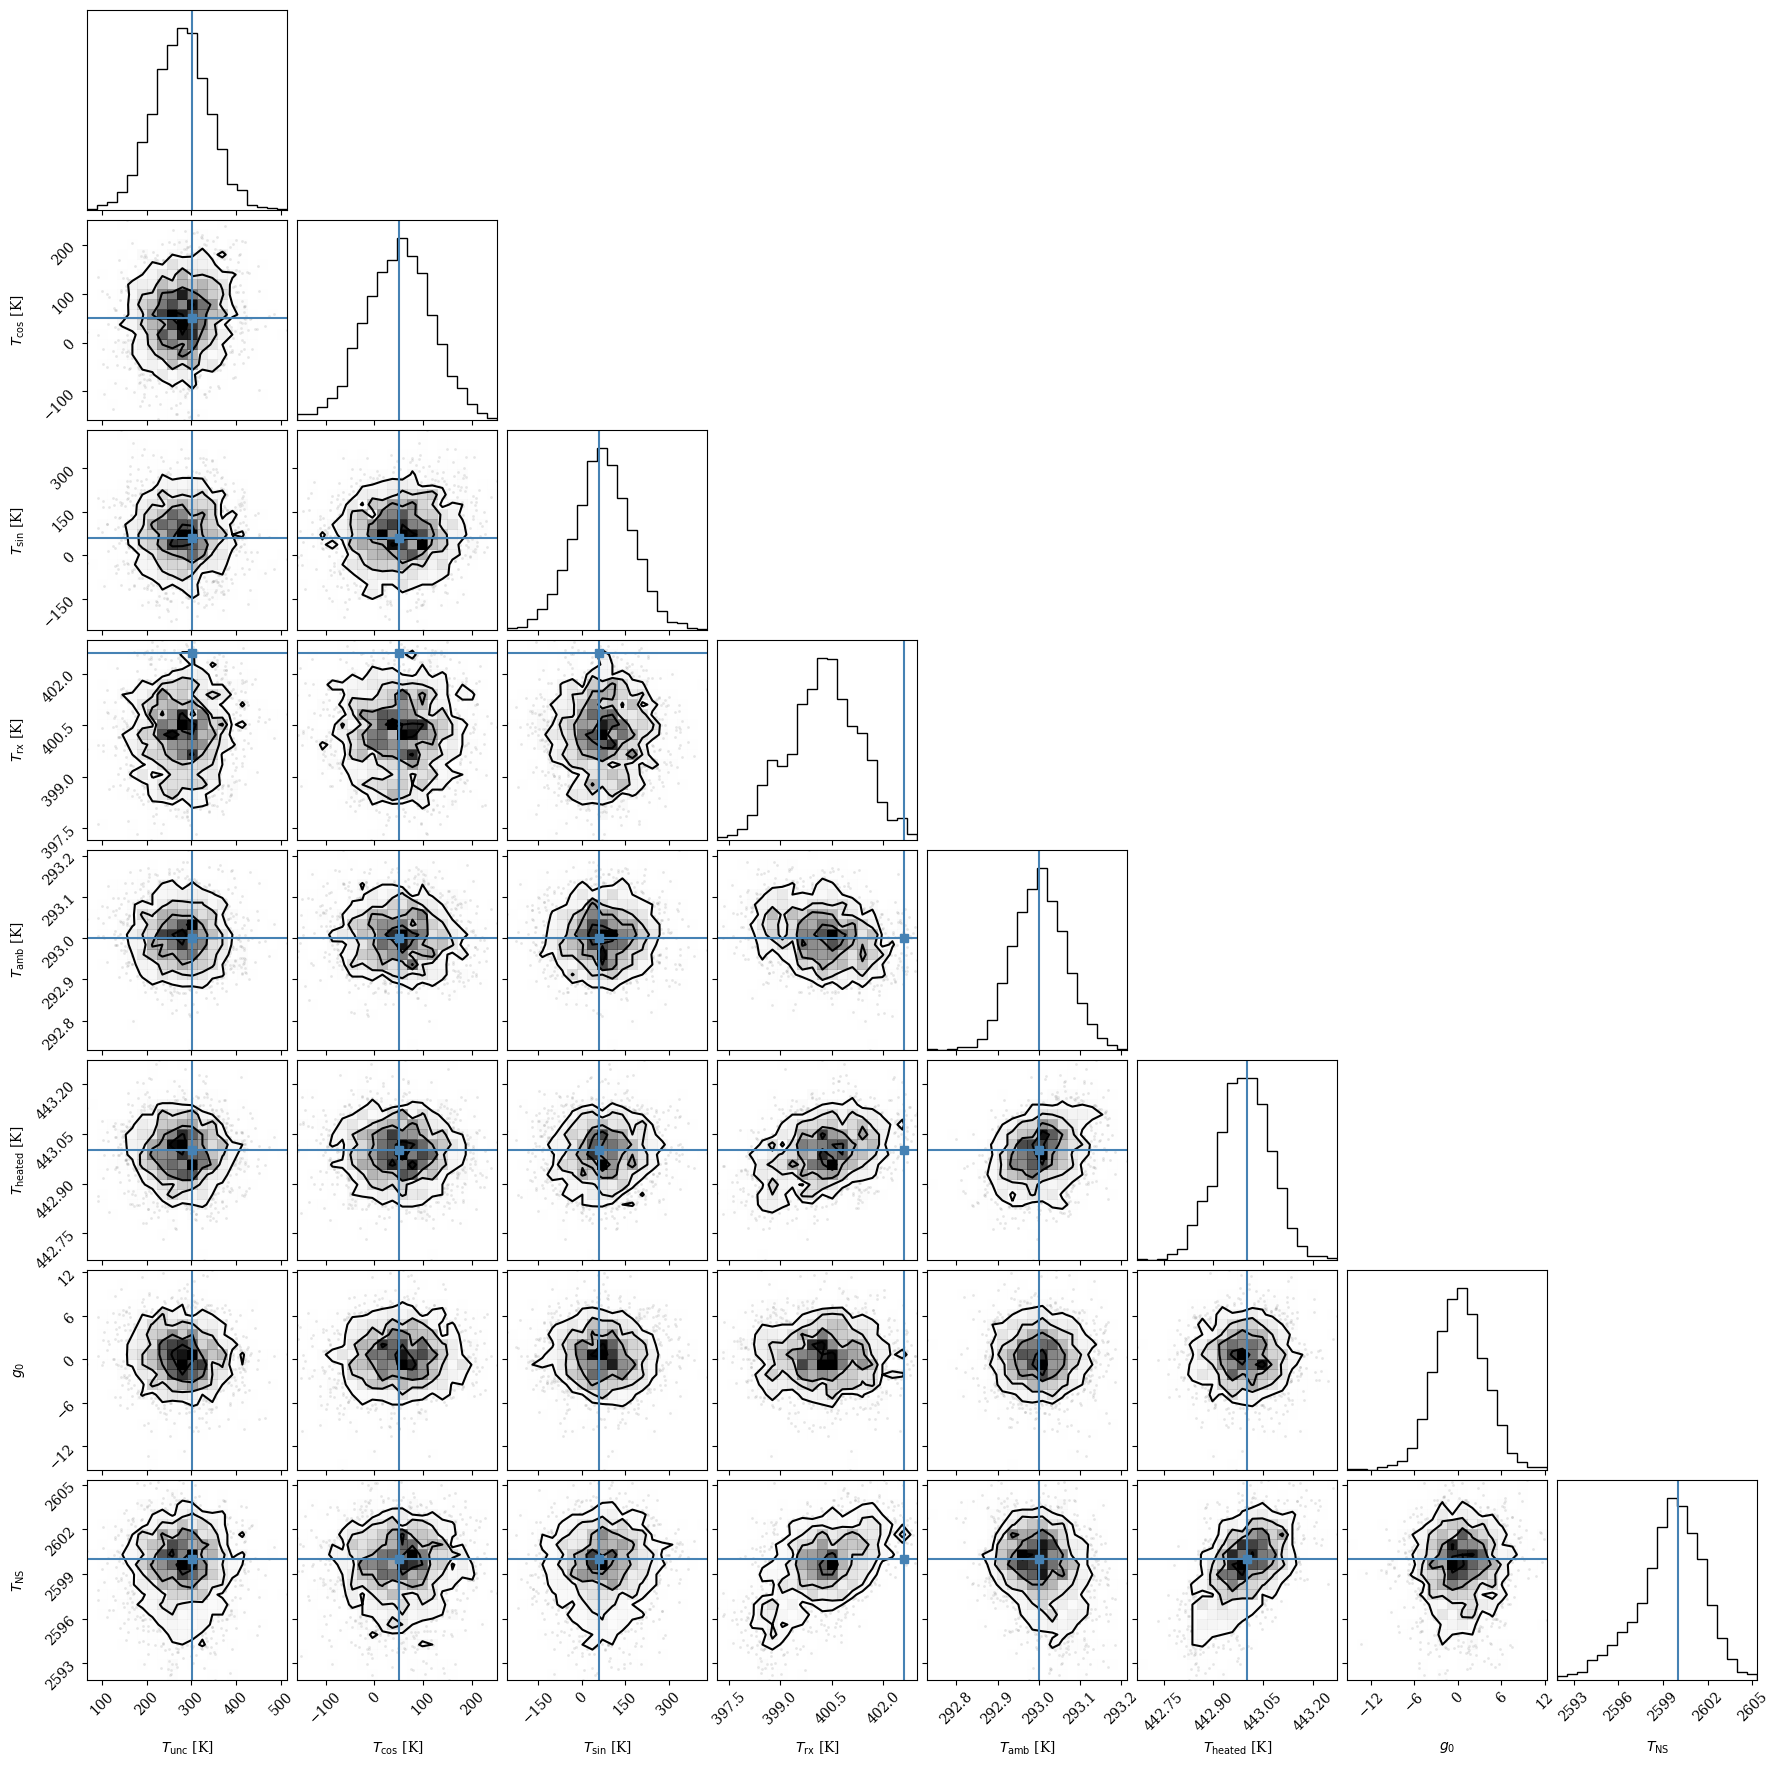

In [465]:

t_unc_chains = noise_wave_chains[:,nw_slice_dict['unc']]
t_sin_chains = noise_wave_chains[:,nw_slice_dict['sin']]
t_cos_chains = noise_wave_chains[:,nw_slice_dict['cos']]
t_rx_chains = noise_wave_chains[:,nw_slice_dict['rx']]

t_amb_chains = param_dict['all_p_cal_src'][:,0]
t_heated_chains = param_dict['all_p_cal_src'][:,1]
print(t_amb_chains, t_heated_chains)

param_dict['all_p_gain']

gain_chain = param_dict['all_p_gain'][:,-1]



chains = np.column_stack([
    t_unc_chains[:,-1],
    t_cos_chains[:,-1],
    t_sin_chains[:,-1],
    t_rx_chains[:,-1],
    t_amb_chains,
    t_heated_chains,
    gain_chain,
    noise_diode_chain[:,-1]
])

fig = plot_corner(
    chains,
    labels=[
        r'$T_{\rm unc}$ [K]',
        r'$T_{\rm cos}$ [K]',
        r'$T_{\rm sin}$ [K]',
        r'$T_{\rm rx}$ [K]',
        r'$T_{\rm amb}$ [K]',
        r'$T_{\rm heated}$ [K]',
        r'$g_0$',
        r'$T_{\rm NS}$'
    ],
    truths=[
        np.mean(t_unc_sim),
        np.mean(t_cos_sim),
        np.mean(t_sin_sim),
        np.mean(t_rx_sim),
        293,
        293+150,
        np.mean(gain_sim),
        2600
    ]
)

plt.show()

# Construct $z$-score waterfall

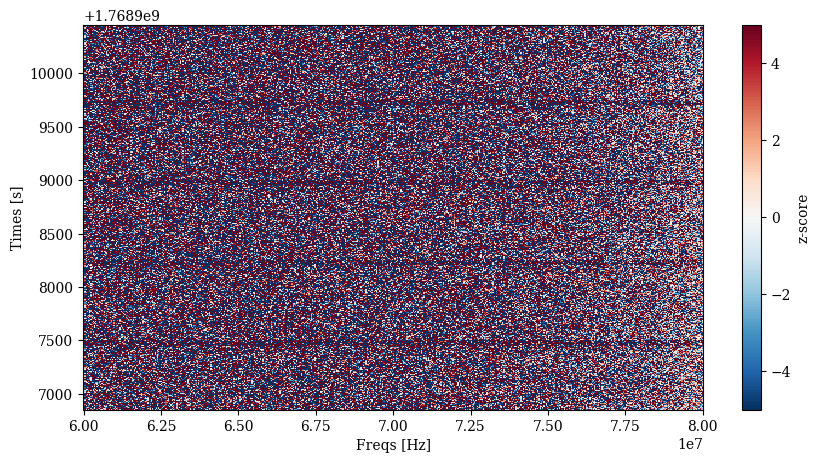

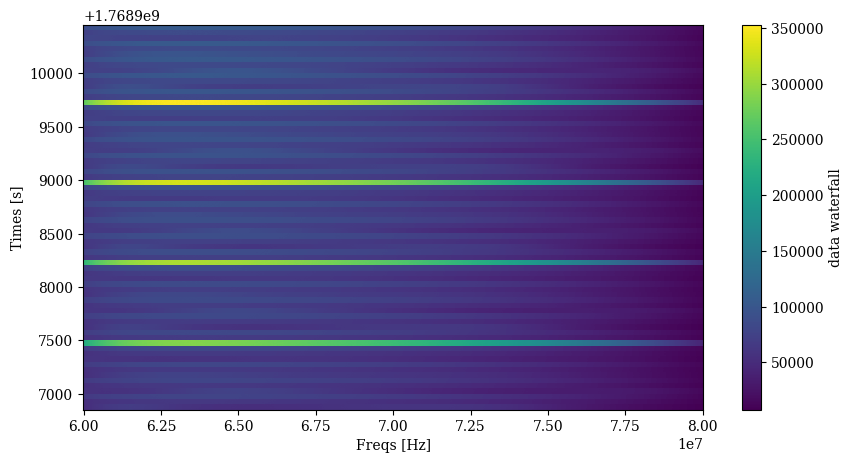

7.210130015141394


In [466]:
mad_model = (gains_basis.basis_matrix @ param_dict['all_p_gain'].mean(axis=0)) *\
    ((X_ant_noisewave @ param_dict['all_p_ant_nw'].mean(axis=0) + X_calibrator @ param_dict['all_p_cal_src'].mean(axis=0)))

cov = observation.Nw.flatten() * mad_model
sigma = np.sqrt(cov)
del cov

z = (observation.data_waterfall.flatten() - mad_model) / sigma
z = np.reshape(z, observation.data_waterfall.shape)

plt.pcolormesh(observation.freqs,
               observation.times,
               z,
               vmin=-5,
               vmax=5,
               cmap='RdBu_r')
plt.colorbar(label='z-score')
plt.ylabel('Times [s]')
plt.xlabel('Freqs [Hz]')
plt.show()


plt.pcolormesh(observation.freqs,
               observation.times,
               observation.data_waterfall,)
plt.colorbar(label='data waterfall')
plt.ylabel('Times [s]')
plt.xlabel('Freqs [Hz]')
plt.show()

print(np.median(np.abs(z)))

### Plotting for the spectral, time static case.

Create plots of the various 